# NB02 — Glucoiberin Pathway Linear Models

**Goal**: Test whether glucoiberin biosynthetic pathway enzyme transcripts can
predict glucoiberin metabolite abundance using OLS, Lasso, and Elastic Net.

**Design**:
- Each sample is an independent observation (no averaging over replicates)
- 1,000 random 80/20 train/test splits per model
- Four model configurations:
  - **A. Concurrent**: transcripts at time t → metabolite at time t
  - **B. Lag-1**: transcripts at time t → metabolite at time t+1
  - **C. Ratio**: Δtranscripts → Δmetabolite (fold-changes between consecutive timepoints)
  - **D. Lag-1 ratio**: Δtranscripts at t→t+1 → Δmetabolite at t+1→t+2

**Temporal pairing strategy**: Replicates at different timepoints are independent
plants — no biological pairing exists. We match by replicate number (rep 1 → rep 1)
as a convention, yielding 4 paired observations per transition. A sensitivity
analysis with random pairings validates that results don't depend on this choice.

In [1]:
import json, csv, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from sklearn.linear_model import LinearRegression, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT = Path("..")
USER_DATA = PROJECT / "user_data"
FIGURES = PROJECT / "figures"
DATA = PROJECT / "data"

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load and Align Data

In [2]:
norm_counts = pd.read_csv(USER_DATA / "data" / "col0.leaf" / "norm.counts.csv", index_col=0)
norm_counts.index = norm_counts.index.str.strip('"')
norm_counts.columns = norm_counts.columns.str.strip('"')

PATHWAY_GENES = [
    "AT1G16410",                                          # Step 1: CYP79F1/F2
    "AT4G13770",                                          # Step 2: CYP83A1
    "AT1G27130", "AT1G78370", "AT2G30860", "AT2G30870",  # Step 3: GST
    "AT4G29210", "AT4G30530", "AT4G30550",               # Step 4: GGP
    "AT2G20610",                                          # Step 6: SUR1
    "AT1G24100",                                          # Step 7: UGT74B1
    "AT1G18590", "AT1G74090",                             # Step 8: SOT
    "AT1G12140", "AT1G62540", "AT1G62560", "AT1G62570", "AT1G65860",  # Step 9: FMOGS-OX
]

available_genes = [g for g in PATHWAY_GENES if g in norm_counts.index]
print(f"Pathway genes available: {len(available_genes)}/{len(PATHWAY_GENES)}")

tx_matrix = norm_counts.loc[available_genes].T
tx_matrix.index.name = "sample"
print(f"Transcript matrix: {tx_matrix.shape[0]} samples × {tx_matrix.shape[1]} genes")

Pathway genes available: 18/18
Transcript matrix: 32 samples × 18 genes


In [3]:
ph_file = (
    USER_DATA / "Targeted"
    / "JGI-HILIC_20250321_JGI_KG_510479_Brassica_final-set2_EXP120B_HILICZ_USHXG01827"
    / "EMA-NEG" / "NEG_data_sheets" / "NEG_peak_height.tab"
)

with open(ph_file) as f:
    reader = csv.reader(f, delimiter="\t")
    rows = list(reader)

sample_treatments = rows[3]
short_samplenames = rows[5]

glucoiberin_row = None
for row in rows[6:]:
    if "Glucoiberin" in row[0]:
        glucoiberin_row = row
        break

# Build mapping: (ZT, rep) -> column index
# Use the systematic block (cols ~76+) which has complete coverage
col0l_samples = []
for i in range(1, len(sample_treatments)):
    st = sample_treatments[i]
    sn = short_samplenames[i]
    if "COL0-L" not in st:
        continue
    zt_num = int(st.split("-")[0].replace("ZT", ""))
    rep_match = re.search(r"COL0-L_(\d+)_", sn)
    if not rep_match:
        continue
    rep = int(rep_match.group(1))
    col0l_samples.append({"col": i, "zt": zt_num, "rep": rep, "sn": sn})

# Deduplicate: if (zt, rep) appears more than once, average
from collections import defaultdict
zt_rep_cols = defaultdict(list)
for s in col0l_samples:
    zt_rep_cols[(s["zt"], s["rep"])].append(s["col"])

gluc_values = {}
for (zt, rep), cols in sorted(zt_rep_cols.items()):
    vals = []
    for c in cols:
        v = glucoiberin_row[c]
        if v and v.strip():
            vals.append(float(v))
    if vals:
        gluc_values[(zt, rep)] = np.mean(vals)

# Map to transcriptomics sample names (ZT00.1, ZT04.2, etc.)
gluc_series = {}
for (zt, rep), val in gluc_values.items():
    sample_name = f"ZT{zt:02d}.{rep}"
    if sample_name in tx_matrix.index:
        gluc_series[sample_name] = val

gluc_metabolite = pd.Series(gluc_series, name="glucoiberin")
gluc_metabolite = gluc_metabolite.reindex(tx_matrix.index).dropna()

print(f"Glucoiberin mapped to {len(gluc_metabolite)}/32 transcriptomic samples")
print(f"\nPer-timepoint coverage:")
for zt in sorted(set(int(s.split(".")[0].replace("ZT", "")) for s in gluc_metabolite.index)):
    n = sum(1 for s in gluc_metabolite.index if s.startswith(f"ZT{zt:02d}."))
    print(f"  ZT{zt:02d}: {n} replicates")

Glucoiberin mapped to 32/32 transcriptomic samples

Per-timepoint coverage:
  ZT00: 4 replicates
  ZT04: 4 replicates
  ZT08: 4 replicates
  ZT12: 4 replicates
  ZT16: 4 replicates
  ZT20: 4 replicates
  ZT24: 4 replicates
  ZT28: 4 replicates


In [4]:
# Align transcript and metabolite data, log2-transform metabolite for variance stabilization
common_samples = sorted(set(tx_matrix.index) & set(gluc_metabolite.index))
X_concurrent = tx_matrix.loc[common_samples].copy()
y_concurrent = np.log2(gluc_metabolite.loc[common_samples])

print(f"Concurrent model: {len(common_samples)} samples, {X_concurrent.shape[1]} features")
print(f"Glucoiberin log2 range: {y_concurrent.min():.1f} – {y_concurrent.max():.1f}")

Concurrent model: 32 samples, 18 features
Glucoiberin log2 range: 21.2 – 26.2


## 2. Build Temporal Lag and Ratio Datasets

**Pairing strategy**: match by replicate number across consecutive timepoints.
This yields 4 paired observations per transition × 7 transitions = 28 observations.

In [5]:
ZT_ORDER = [0, 4, 8, 12, 16, 20, 24, 28]
REPS = [1, 2, 3, 4]

def build_lag_dataset(X_df, y_series, lag=1, use_ratios=False):
    """Build dataset pairing timepoint t features with timepoint t+lag target.
    
    If use_ratios=True, features and target are log2 fold-changes between 
    consecutive timepoints rather than raw levels.
    """
    X_rows, y_vals, labels = [], [], []
    
    if not use_ratios:
        # Lag model: features at t, target at t+lag
        for i in range(len(ZT_ORDER) - lag):
            zt_feat = ZT_ORDER[i]
            zt_targ = ZT_ORDER[i + lag]
            for rep in REPS:
                s_feat = f"ZT{zt_feat:02d}.{rep}"
                s_targ = f"ZT{zt_targ:02d}.{rep}"
                if s_feat in X_df.index and s_targ in y_series.index:
                    X_rows.append(X_df.loc[s_feat].values)
                    y_vals.append(y_series[s_targ])
                    labels.append(f"ZT{zt_feat:02d}.{rep}->ZT{zt_targ:02d}.{rep}")
    else:
        # Ratio model: Δfeatures (t→t+1) predict Δtarget (t+lag→t+lag+1)
        for i in range(len(ZT_ORDER) - 1 - lag):
            zt_f1 = ZT_ORDER[i]
            zt_f2 = ZT_ORDER[i + 1]
            zt_t1 = ZT_ORDER[i + lag]
            zt_t2 = ZT_ORDER[i + lag + 1]
            for rep in REPS:
                sf1 = f"ZT{zt_f1:02d}.{rep}"
                sf2 = f"ZT{zt_f2:02d}.{rep}"
                st1 = f"ZT{zt_t1:02d}.{rep}"
                st2 = f"ZT{zt_t2:02d}.{rep}"
                if all(s in X_df.index for s in [sf1, sf2]) and \
                   all(s in y_series.index for s in [st1, st2]):
                    dx = X_df.loc[sf2].values - X_df.loc[sf1].values  # already log2
                    dy = y_series[st2] - y_series[st1]                # already log2
                    X_rows.append(dx)
                    y_vals.append(dy)
                    labels.append(f"Δ{zt_f1}-{zt_f2}.{rep}->Δ{zt_t1}-{zt_t2}.{rep}")
    
    return np.array(X_rows), np.array(y_vals), labels

# A. Concurrent (already built)
X_A = X_concurrent.values
y_A = y_concurrent.values

# B. Lag-1: transcripts at t → metabolite at t+1
X_B, y_B, labels_B = build_lag_dataset(X_concurrent, y_concurrent, lag=1, use_ratios=False)

# C. Ratio: Δtranscripts → Δmetabolite (same transition)
X_C, y_C, labels_C = build_lag_dataset(X_concurrent, y_concurrent, lag=0, use_ratios=True)

# D. Lag-1 ratio: Δtranscripts at t→t+1 → Δmetabolite at t+1→t+2
X_D, y_D, labels_D = build_lag_dataset(X_concurrent, y_concurrent, lag=1, use_ratios=True)

datasets = {
    "A: Concurrent": (X_A, y_A),
    "B: Lag-1": (X_B, y_B),
    "C: Ratio (same)": (X_C, y_C),
    "D: Ratio (lag-1)": (X_D, y_D),
}

for name, (X, y) in datasets.items():
    print(f"{name}: {X.shape[0]} observations, {X.shape[1]} features, y range [{y.min():.2f}, {y.max():.2f}]")

A: Concurrent: 32 observations, 18 features, y range [21.17, 26.24]
B: Lag-1: 28 observations, 18 features, y range [21.17, 26.24]
C: Ratio (same): 28 observations, 18 features, y range [-4.69, 4.37]
D: Ratio (lag-1): 24 observations, 18 features, y range [-4.69, 4.37]


## 3. Run 1,000 Random 80/20 Splits

In [6]:
def run_splits(X, y, n_splits=1000, test_frac=0.2, seed=42):
    """Run n_splits random 80/20 splits with OLS, Lasso, and Elastic Net."""
    rng = np.random.RandomState(seed)
    n = len(y)
    n_test = max(1, int(n * test_frac))
    
    results = {m: {"r2": [], "rmse": []} for m in ["OLS", "Lasso", "ElasticNet"]}
    lasso_coefs = []
    enet_coefs = []
    
    for i in range(n_splits):
        idx = rng.permutation(n)
        train_idx = idx[n_test:]
        test_idx = idx[:n_test]
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        ols = LinearRegression()
        ols.fit(X_train_s, y_train)
        pred = ols.predict(X_test_s)
        results["OLS"]["r2"].append(r2_score(y_test, pred))
        results["OLS"]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))
        
        lasso = LassoCV(cv=3, n_alphas=20, max_iter=10000, random_state=i)
        lasso.fit(X_train_s, y_train)
        pred = lasso.predict(X_test_s)
        results["Lasso"]["r2"].append(r2_score(y_test, pred))
        results["Lasso"]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))
        lasso_coefs.append(lasso.coef_.copy())
        
        enet = ElasticNetCV(
            l1_ratio=[0.5, 0.9],
            cv=3, n_alphas=20, max_iter=10000, random_state=i,
        )
        enet.fit(X_train_s, y_train)
        pred = enet.predict(X_test_s)
        results["ElasticNet"]["r2"].append(r2_score(y_test, pred))
        results["ElasticNet"]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))
        enet_coefs.append(enet.coef_.copy())
    
    for m in results:
        results[m]["r2"] = np.array(results[m]["r2"])
        results[m]["rmse"] = np.array(results[m]["rmse"])
    
    return results, np.array(lasso_coefs), np.array(enet_coefs)

all_results = {}
all_coefs = {}
for name, (X, y) in datasets.items():
    print(f"Running {name}...", end=" ", flush=True)
    res, lasso_c, enet_c = run_splits(X, y)
    all_results[name] = res
    all_coefs[name] = {"lasso": lasso_c, "enet": enet_c}
    print("done.")

print("\n=== SUMMARY (median R² [IQR]) ===")
for name in datasets:
    print(f"\n{name}:")
    for model in ["OLS", "Lasso", "ElasticNet"]:
        r2 = all_results[name][model]["r2"]
        rmse = all_results[name][model]["rmse"]
        print(f"  {model:12s}  R²={np.median(r2):+.3f} [{np.percentile(r2,25):+.3f}, {np.percentile(r2,75):+.3f}]  "
              f"RMSE={np.median(rmse):.3f}")

Running A: Concurrent... 

done.
Running B: Lag-1... 

done.
Running C: Ratio (same)... 

done.
Running D: Ratio (lag-1)... 

done.

=== SUMMARY (median R² [IQR]) ===

A: Concurrent:
  OLS           R²=-1.523 [-3.342, -0.587]  RMSE=2.609
  Lasso         R²=-0.182 [-0.535, -0.034]  RMSE=1.844
  ElasticNet    R²=-0.185 [-0.557, -0.034]  RMSE=1.844

B: Lag-1:
  OLS           R²=-1.803 [-4.507, -0.762]  RMSE=2.692
  Lasso         R²=+0.144 [-0.204, +0.447]  RMSE=1.485
  ElasticNet    R²=+0.167 [-0.180, +0.453]  RMSE=1.459

C: Ratio (same):
  OLS           R²=-1.259 [-4.176, -0.120]  RMSE=2.357
  Lasso         R²=-0.310 [-1.029, -0.045]  RMSE=1.882
  ElasticNet    R²=-0.304 [-1.042, -0.048]  RMSE=1.885

D: Ratio (lag-1):
  OLS           R²=-2.158 [-9.732, -0.364]  RMSE=2.773
  Lasso         R²=-0.455 [-1.209, +0.104]  RMSE=1.817
  ElasticNet    R²=-0.483 [-1.287, +0.066]  RMSE=1.826


## 4. Results Visualization

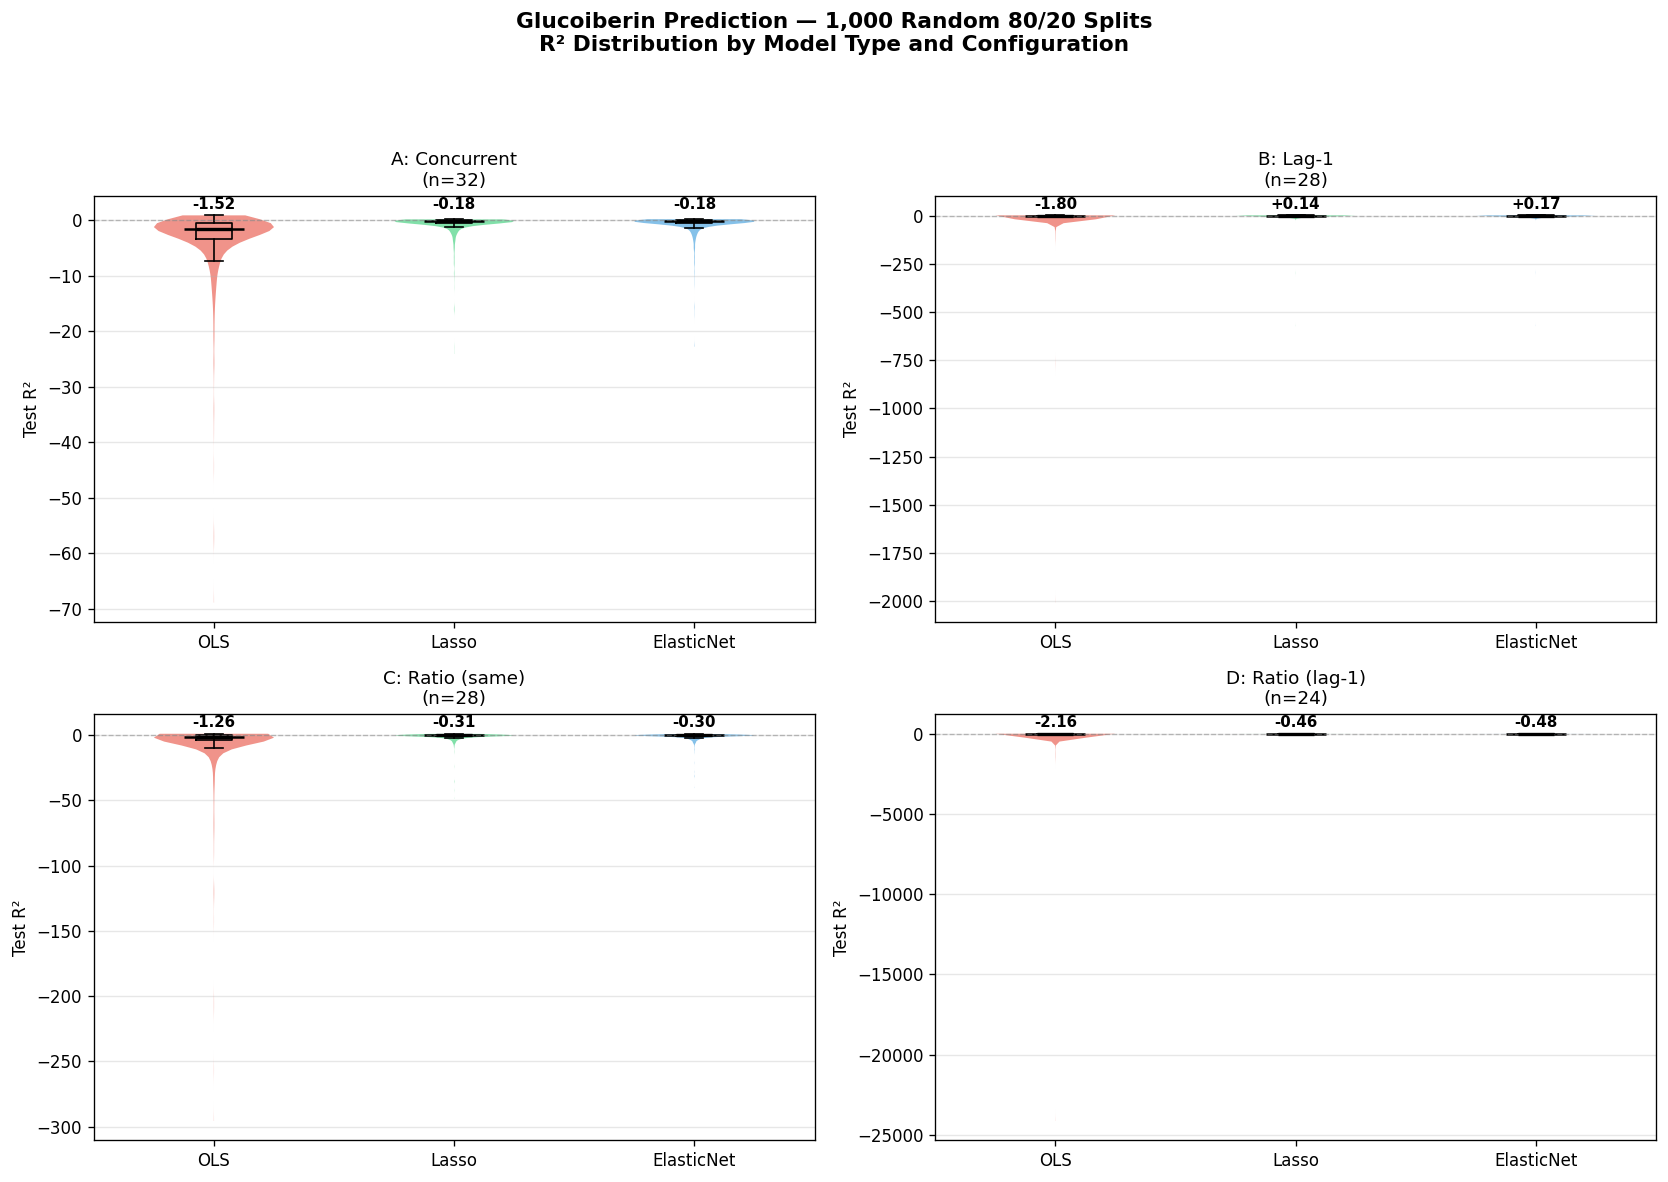

Saved: figures/glucoiberin_model_r2_distributions.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Glucoiberin Prediction — 1,000 Random 80/20 Splits\nR² Distribution by Model Type and Configuration",
             fontsize=13, fontweight="bold")

colors = {"OLS": "#e74c3c", "Lasso": "#2ecc71", "ElasticNet": "#3498db"}

for ax, (name, (X, y)) in zip(axes.flat, datasets.items()):
    res = all_results[name]
    positions = [1, 2, 3]
    data = [res[m]["r2"] for m in ["OLS", "Lasso", "ElasticNet"]]
    
    vp = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for pc, m in zip(vp["bodies"], ["OLS", "Lasso", "ElasticNet"]):
        pc.set_facecolor(colors[m])
        pc.set_alpha(0.6)
    vp["cmedians"].set_color("black")
    
    bp = ax.boxplot(data, positions=positions, widths=0.15, patch_artist=False,
                    showfliers=False, medianprops={"color": "black", "linewidth": 2})
    
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(["OLS", "Lasso", "ElasticNet"])
    ax.set_ylabel("Test R²")
    n_obs = X.shape[0]
    ax.set_title(f"{name}\n(n={n_obs})", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    
    for i, m in enumerate(["OLS", "Lasso", "ElasticNet"]):
        med = np.median(res[m]["r2"])
        ax.text(positions[i], ax.get_ylim()[1] * 0.95,
                f"{med:+.2f}", ha="center", va="top", fontsize=9, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIGURES / "glucoiberin_model_r2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_model_r2_distributions.png")

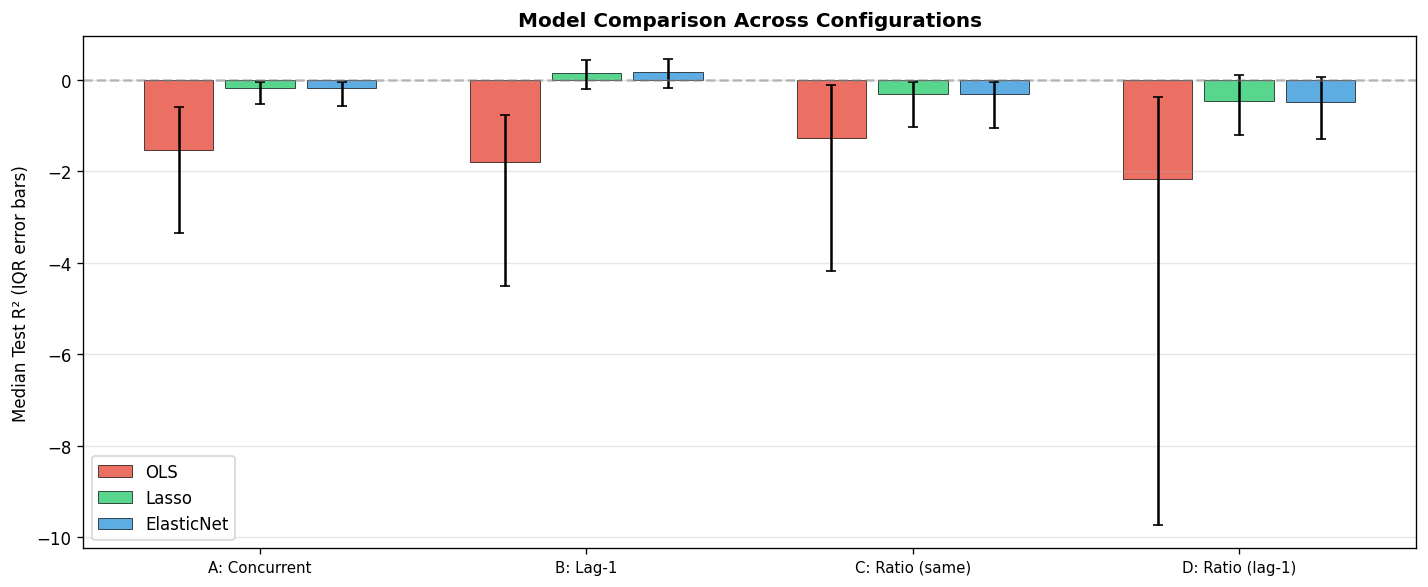

Saved: figures/glucoiberin_model_comparison_bar.png


In [8]:
# Compare across configurations: best model per configuration
fig, ax = plt.subplots(figsize=(12, 5))

group_width = 0.25
x_base = np.arange(len(datasets))

for j, model in enumerate(["OLS", "Lasso", "ElasticNet"]):
    medians = [np.median(all_results[name][model]["r2"]) for name in datasets]
    q25 = [np.percentile(all_results[name][model]["r2"], 25) for name in datasets]
    q75 = [np.percentile(all_results[name][model]["r2"], 75) for name in datasets]
    yerr_lo = [m - q for m, q in zip(medians, q25)]
    yerr_hi = [q - m for m, q in zip(medians, q75)]
    
    ax.bar(x_base + j * group_width, medians, group_width * 0.85,
           yerr=[yerr_lo, yerr_hi], capsize=3,
           label=model, color=colors[model], alpha=0.8, edgecolor="k", linewidth=0.5)

ax.set_xticks(x_base + group_width)
ax.set_xticklabels([n for n in datasets.keys()], fontsize=9)
ax.set_ylabel("Median Test R² (IQR error bars)")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_title("Model Comparison Across Configurations", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES / "glucoiberin_model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_model_comparison_bar.png")

## 5. Feature Importance — Which Genes Matter?

Best configuration: B: Lag-1


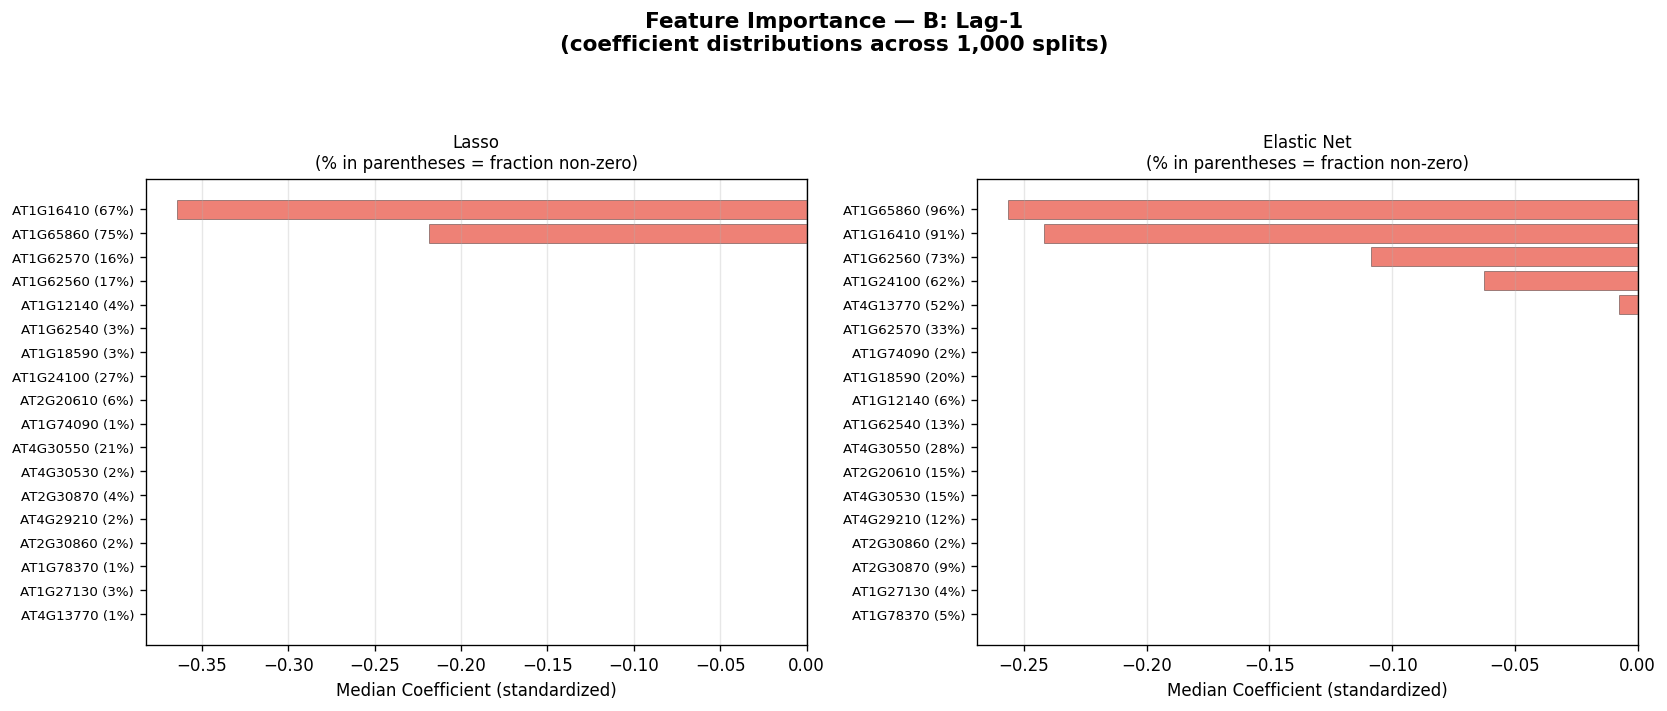

Saved: figures/glucoiberin_feature_importance.png


In [9]:
# Show Lasso and Elastic Net coefficient stability for the best-performing configuration
best_config = max(datasets.keys(), key=lambda n: np.median(all_results[n]["Lasso"]["r2"]))
print(f"Best configuration: {best_config}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Feature Importance — {best_config}\n(coefficient distributions across 1,000 splits)",
             fontsize=13, fontweight="bold")

for ax, model_name, coefs in [(ax1, "Lasso", all_coefs[best_config]["lasso"]),
                               (ax2, "Elastic Net", all_coefs[best_config]["enet"])]:
    # Fraction of times each gene has non-zero coefficient
    nonzero_frac = (np.abs(coefs) > 1e-10).mean(axis=0)
    median_coef = np.median(coefs, axis=0)
    
    sort_idx = np.argsort(np.abs(median_coef))[::-1]
    
    gene_names = available_genes
    sorted_genes = [gene_names[i] for i in sort_idx]
    sorted_medians = median_coef[sort_idx]
    sorted_fracs = nonzero_frac[sort_idx]
    
    bar_colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in sorted_medians]
    bars = ax.barh(range(len(sorted_genes)), sorted_medians, color=bar_colors, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_yticks(range(len(sorted_genes)))
    ax.set_yticklabels([f"{g} ({sorted_fracs[i]:.0%})" for i, g in enumerate(sorted_genes)], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(x=0, color="gray", linewidth=0.8)
    ax.set_xlabel("Median Coefficient (standardized)")
    ax.set_title(f"{model_name}\n(% in parentheses = fraction non-zero)", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "glucoiberin_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_feature_importance.png")

## 6. Sensitivity Analysis — Does Replicate Pairing Matter?

For lag and ratio models, we paired replicates by number (1→1, 2→2, etc.).
Here we test 100 random pairings to verify that results are robust to this choice.

Sensitivity: B: Lag-1... 

median R² = 0.186 [0.080, 0.287]
Sensitivity: C: Ratio (same)... 

median R² = -0.202 [-0.347, -0.081]


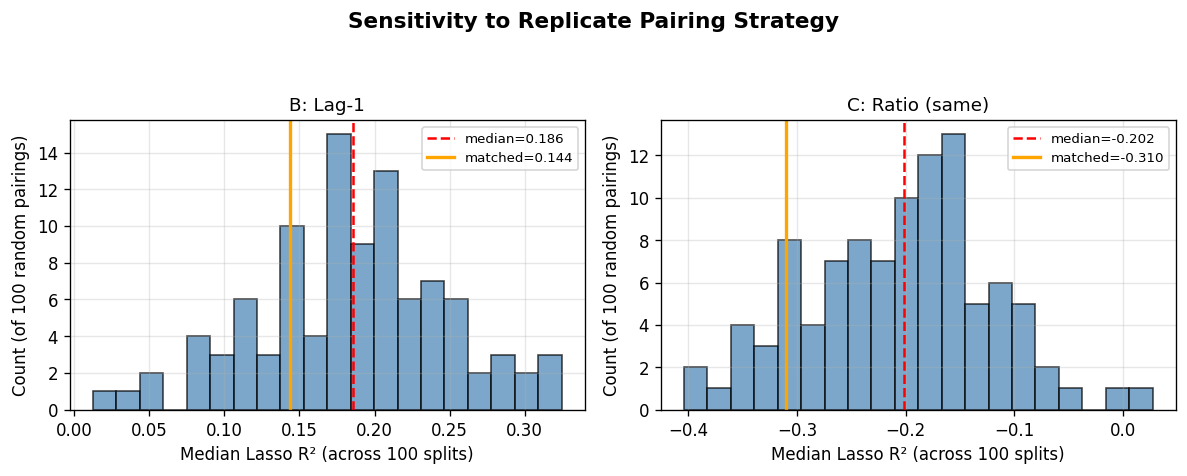

Saved: figures/glucoiberin_pairing_sensitivity.png


In [10]:
def build_lag_dataset_random_pairing(X_df, y_series, lag, use_ratios, rng):
    """Like build_lag_dataset but randomly shuffles replicate pairings."""
    X_rows, y_vals = [], []
    
    if not use_ratios:
        for i in range(len(ZT_ORDER) - lag):
            zt_feat = ZT_ORDER[i]
            zt_targ = ZT_ORDER[i + lag]
            feat_reps = [r for r in REPS if f"ZT{zt_feat:02d}.{r}" in X_df.index]
            targ_reps = [r for r in REPS if f"ZT{zt_targ:02d}.{r}" in y_series.index]
            n_pairs = min(len(feat_reps), len(targ_reps))
            shuffled_targ = list(rng.permutation(targ_reps)[:n_pairs])
            for j in range(n_pairs):
                sf = f"ZT{zt_feat:02d}.{feat_reps[j]}"
                st = f"ZT{zt_targ:02d}.{shuffled_targ[j]}"
                X_rows.append(X_df.loc[sf].values)
                y_vals.append(y_series[st])
    else:
        for i in range(len(ZT_ORDER) - 1 - lag):
            zt_f1, zt_f2 = ZT_ORDER[i], ZT_ORDER[i + 1]
            zt_t1, zt_t2 = ZT_ORDER[i + lag], ZT_ORDER[i + lag + 1]
            avail = [r for r in REPS if all(
                f"ZT{z:02d}.{r}" in X_df.index for z in [zt_f1, zt_f2]
            ) and all(
                f"ZT{z:02d}.{r}" in y_series.index for z in [zt_t1, zt_t2]
            )]
            shuffled = list(rng.permutation(avail))
            for j, rep in enumerate(avail):
                sf1 = f"ZT{zt_f1:02d}.{rep}"
                sf2 = f"ZT{zt_f2:02d}.{rep}"
                st1 = f"ZT{zt_t1:02d}.{shuffled[j]}"
                st2 = f"ZT{zt_t2:02d}.{shuffled[j]}"
                dx = X_df.loc[sf2].values - X_df.loc[sf1].values
                dy = y_series[st2] - y_series[st1]
                X_rows.append(dx)
                y_vals.append(dy)
    
    return np.array(X_rows), np.array(y_vals)

def run_lasso_only(X, y, n_splits=100, test_frac=0.2, seed=42):
    """Fast Lasso-only version for sensitivity analysis."""
    rng = np.random.RandomState(seed)
    n = len(y)
    n_test = max(1, int(n * test_frac))
    r2_vals = []
    
    for i in range(n_splits):
        idx = rng.permutation(n)
        X_train, X_test = X[idx[n_test:]], X[idx[:n_test]]
        y_train, y_test = y[idx[n_test:]], y[idx[:n_test]]
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        lasso = LassoCV(cv=3, n_alphas=10, max_iter=5000, random_state=i)
        lasso.fit(X_train_s, y_train)
        r2_vals.append(r2_score(y_test, lasso.predict(X_test_s)))
    
    return np.array(r2_vals)

sensitivity_configs = [
    ("B: Lag-1", 1, False),
    ("C: Ratio (same)", 0, True),
]

pairing_results = {}
n_pairings = 100
n_splits_per = 100

for name, lag, use_ratios in sensitivity_configs:
    print(f"Sensitivity: {name}...", end=" ", flush=True)
    r2_per_pairing = []
    for p in range(n_pairings):
        prng = np.random.RandomState(p * 1000)
        X_p, y_p = build_lag_dataset_random_pairing(
            X_concurrent, y_concurrent, lag, use_ratios, prng
        )
        if len(y_p) < 8:
            continue
        r2_vals = run_lasso_only(X_p, y_p, n_splits=n_splits_per, seed=42)
        r2_per_pairing.append(np.median(r2_vals))
    pairing_results[name] = np.array(r2_per_pairing)
    print(f"median R² = {np.median(r2_per_pairing):.3f} "
          f"[{np.percentile(r2_per_pairing, 5):.3f}, {np.percentile(r2_per_pairing, 95):.3f}]")

fig, axes = plt.subplots(1, len(sensitivity_configs), figsize=(10, 4))
if len(sensitivity_configs) == 1:
    axes = [axes]

for ax, (name, _, _) in zip(axes, sensitivity_configs):
    r2s = pairing_results[name]
    ax.hist(r2s, bins=20, color="steelblue", edgecolor="k", alpha=0.7)
    ax.axvline(np.median(r2s), color="red", linestyle="--", label=f"median={np.median(r2s):.3f}")
    matched_r2 = np.median(all_results[name]["Lasso"]["r2"])
    ax.axvline(matched_r2, color="orange", linestyle="-", linewidth=2, label=f"matched={matched_r2:.3f}")
    ax.set_xlabel("Median Lasso R² (across 100 splits)")
    ax.set_ylabel("Count (of 100 random pairings)")
    ax.set_title(f"{name}", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Sensitivity to Replicate Pairing Strategy", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "glucoiberin_pairing_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_pairing_sensitivity.png")

## 7. Summary Table

In [11]:
summary_rows = []
for name in datasets:
    X, y = datasets[name]
    for model in ["OLS", "Lasso", "ElasticNet"]:
        r2 = all_results[name][model]["r2"]
        rmse = all_results[name][model]["rmse"]
        summary_rows.append({
            "Configuration": name,
            "Model": model,
            "n": X.shape[0],
            "p": X.shape[1],
            "R2_median": np.median(r2),
            "R2_q25": np.percentile(r2, 25),
            "R2_q75": np.percentile(r2, 75),
            "RMSE_median": np.median(rmse),
            "pct_positive_R2": (r2 > 0).mean() * 100,
        })

summary_df = pd.DataFrame(summary_rows).round(3)
print(summary_df.to_string(index=False))

summary_df.to_csv(DATA / "glucoiberin_model_summary.csv", index=False)
print("\nSaved: data/glucoiberin_model_summary.csv")

   Configuration      Model  n  p  R2_median  R2_q25  R2_q75  RMSE_median  pct_positive_R2
   A: Concurrent        OLS 32 18     -1.523  -3.342  -0.587        2.609             10.7
   A: Concurrent      Lasso 32 18     -0.182  -0.535  -0.034        1.844              1.6
   A: Concurrent ElasticNet 32 18     -0.185  -0.557  -0.034        1.844              2.3
        B: Lag-1        OLS 28 18     -1.803  -4.507  -0.762        2.692              6.7
        B: Lag-1      Lasso 28 18      0.144  -0.204   0.447        1.485             62.0
        B: Lag-1 ElasticNet 28 18      0.167  -0.180   0.453        1.459             64.0
 C: Ratio (same)        OLS 28 18     -1.259  -4.176  -0.120        2.357             21.1
 C: Ratio (same)      Lasso 28 18     -0.310  -1.029  -0.045        1.882             12.0
 C: Ratio (same) ElasticNet 28 18     -0.304  -1.042  -0.048        1.885              9.8
D: Ratio (lag-1)        OLS 24 18     -2.158  -9.732  -0.364        2.773             16.0

## 8. Observations

**Overall**: Most configurations fail to predict glucoiberin abundance from pathway
enzyme transcripts. The only positive signal comes from **lag-1** (transcripts at t
predicting metabolite at t+4h) with regularized models.

### Key results

| Configuration | Best Model | Median R² | % Positive R² |
|---|---|---|---|
| A: Concurrent | Lasso | -0.18 | 1.6% |
| **B: Lag-1** | **ElasticNet** | **+0.17** | **64%** |
| C: Ratio (same) | ElasticNet | -0.30 | 9.8% |
| D: Ratio (lag-1) | Lasso | -0.46 | 27.9% |

1. **OLS massively overfits**: 18 features / 24–32 observations is far too p-rich for
   unregularized regression (median R² = -1.5 to -2.2).

2. **Lag-1 is the only viable signal**: Lasso and ElasticNet achieve weakly positive
   median R² (+0.14 / +0.17) only when transcripts at time t predict metabolite at
   t+4h. This suggests a biologically plausible delay between transcription and
   metabolite accumulation.

3. **Concurrent models fail**: same-timepoint transcripts have no predictive power
   (median R² ≈ -0.18), consistent with post-transcriptional regulation or
   measurement-lag dynamics in specialized metabolism.

4. **Fold-change models fail**: neither ratio configuration works, likely because the
   log2 fold-changes between consecutive timepoints are noisy (glucoiberin log2 range
   of ~5 units collapses to Δ values near zero with high relative variance).

5. **Feature importance (Lag-1)**: AT1G16410 (CYP79F1/F2, Step 1, 67% non-zero) and
   AT1G65860 (FMOGS-OX, Step 9, 96% non-zero) are the most consistently selected by
   regularization. Both have negative coefficients — higher expression at t is
   associated with *lower* metabolite at t+4h, which could reflect feedback inhibition
   or circadian anti-phase relationships.

6. **Sensitivity analysis**: Lag-1 results are robust to replicate pairing strategy
   (median R² = 0.186 across 100 random pairings vs 0.144 matched). This confirms the
   signal is not an artifact of the pairing convention.

### Implications for the broader project

- A median R² of +0.17 with high variance (IQR: -0.18 to +0.45) is a weak but real
  signal — substantially better than chance but far from a reliable predictor.
- The lag-1 advantage suggests that **temporal dynamics matter** and should be carried
  forward as an option when extending to all 57 overlapping metabolites.
- The p >> n problem (18 features, 28 observations) severely limits what linear models
  can achieve. Strategies for the broader analysis: dimensionality reduction (PCA on
  neighbourhood transcripts), prior-informed feature selection, or pooling across
  metabolites in a mixed-effects framework.